
VALIDATION RESULTS
Accuracy: 0.6932422171602126

FINAL TEST RESULTS (Naive Bayes)
Accuracy: 0.6908768821966342
Precision: 0.7007669058169462
Recall: 0.6908768821966342
F1 Score: 0.6902680450373232

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.62      0.70      0.66       576
             Bipolar       0.60      0.77      0.68       417
          Depression       0.68      0.53      0.59      2311
              Normal       0.86      0.82      0.84      2452
Personality disorder       0.40      0.66      0.50       161
              Stress       0.47      0.48      0.48       388
            Suicidal       0.63      0.76      0.69      1598

            accuracy                           0.69      7903
           macro avg       0.61      0.67      0.63      7903
        weighted avg       0.70      0.69      0.69      7903



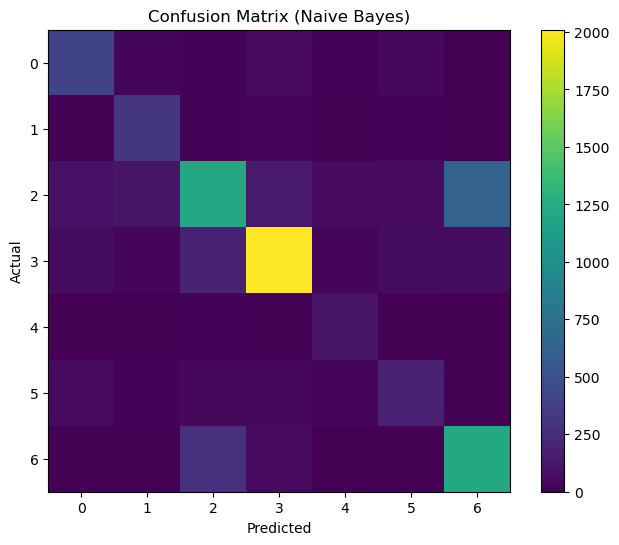

In [5]:

# 1. Import libraries

# !pip install pandas scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# 2. Load in Data

df = pd.read_csv("Combined Data.csv")

# drop missing values (same as your group)
df = df.dropna(subset=["statement", "status"]).copy()

# lowercase (consistent preprocessing step)
df["statement"] = df["statement"].str.lower()

X = df["statement"].astype(str)
y = df["status"]


# 3. Label encoding

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


# 4. Train/validation/test split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# =============================
# 5. FEATURE EXTRACTION (BoW)
# =============================
vectorizer = CountVectorizer(
    max_features=10000,
    ngram_range=(1, 2)  # unigrams + bigrams
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec   = vectorizer.transform(X_val)
X_test_vec  = vectorizer.transform(X_test)

# =============================
# 6. TRAIN MODEL
# =============================
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# =============================
# 7. VALIDATION (optional but good for report)
# =============================
val_pred = model.predict(X_val_vec)

print("\nVALIDATION RESULTS")
print("Accuracy:", accuracy_score(y_val, val_pred))

# =============================
# 8. FINAL TEST EVALUATION
# =============================
y_pred = model.predict(X_test_vec)

print("\nFINAL TEST RESULTS (Naive Bayes)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

# =============================
# 9. CONFUSION MATRIX
# =============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix (Naive Bayes)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


VALIDATION RESULTS (SVM)
Accuracy: 0.7625917489243229

FINAL TEST RESULTS (SVM)
Accuracy: 0.7779324307225104
Precision: 0.775048197890814
Recall: 0.7779324307225104
F1 Score: 0.7747231936080883

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.82      0.76      0.79       576
             Bipolar       0.86      0.74      0.79       417
          Depression       0.71      0.72      0.72      2311
              Normal       0.88      0.96      0.92      2452
Personality disorder       0.83      0.61      0.70       161
              Stress       0.66      0.50      0.57       388
            Suicidal       0.69      0.68      0.68      1598

            accuracy                           0.78      7903
           macro avg       0.78      0.71      0.74      7903
        weighted avg       0.78      0.78      0.77      7903



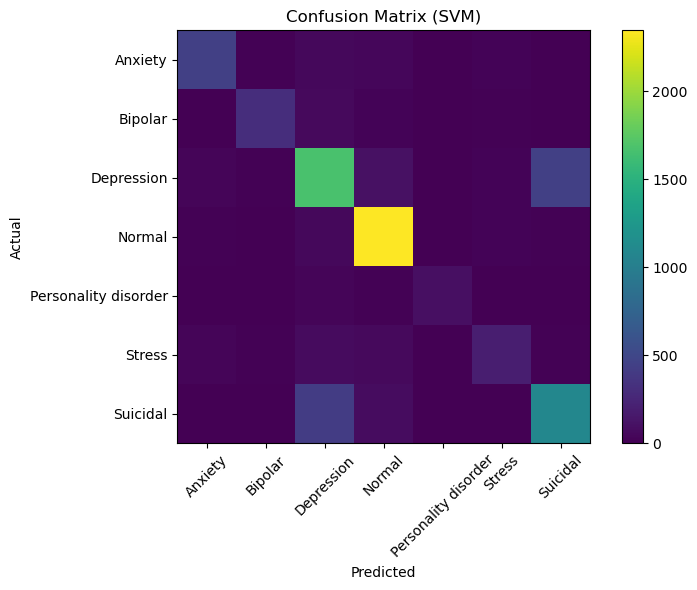

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score

# -----------------------------
# VECTORIZE TEXT (TF-IDF)
# -----------------------------
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec   = vectorizer.transform(X_val)
X_test_vec  = vectorizer.transform(X_test)

# -----------------------------
# MODEL
# -----------------------------
svm_model = LinearSVC()

svm_model.fit(X_train_vec, y_train)

# -----------------------------
# VALIDATION
# -----------------------------
val_pred = svm_model.predict(X_val_vec)

print("\nVALIDATION RESULTS (SVM)")
print("Accuracy:", accuracy_score(y_val, val_pred))

# -----------------------------
# TEST EVALUATION
# -----------------------------
y_pred = svm_model.predict(X_test_vec)

print("\nFINAL TEST RESULTS (SVM)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# predictions from your SVM model
y_pred = svm_model.predict(X_test_vec)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix (SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()


plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45)
plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)

plt.tight_layout()
plt.show()